<a href="https://colab.research.google.com/github/saja-zenaty/test/blob/main/CNN_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

In [34]:
transform = transforms.Compose([
   transforms.ToTensor(),
   transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [35]:
train_data = torchvision.datasets.CIFAR10(root='./data',train=True, download=True, transform=transform)
test_data =  torchvision.datasets.CIFAR10(root='./data',train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data , batch_size=32 , shuffle=True ,num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data , batch_size=32 , shuffle=True ,num_workers=2)

In [36]:
image , label = train_data[0]

In [37]:
print('Images shape : ', image.shape)

Images shape :  torch.Size([3, 32, 32])


In [38]:
class_names = ['plane' ,'car','bird','cat','deer','dog','frog','horse','ship','truck']

# 1. Network Architecture & Model Initialization
This cell defines the `NeuralNet` class, a Deep Convolutional Neural Network (CNN) structured with 6 convolutional layers divided into 3 blocks, followed by 3 fully connected dense layers.

### Key Components:
* **`nn.BatchNorm2d` & `nn.BatchNorm1d`:** Normalizes layer inputs to stabilize training and mitigate vanishing gradients.
* **`nn.MaxPool2d`:** Downsamples spatial dimensions by a factor of 2 after each block to reduce computational load.
* **`nn.Dropout`:** Randomly deactivates neurons during training to enforce feature redundancy and mitigate overfitting.
* **Optimization Setup:** Initializes the Adam optimizer with a learning rate of 0.001 and defines Cross-Entropy Loss for multi-class classification on the 10 CIFAR-10 categories.

In [39]:
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.3)

        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout(0.4)

        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.bn7 = nn.BatchNorm1d(512)
        self.drop4 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.drop1(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.drop2(x)

        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)
        x = self.drop3(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.bn7(self.fc1(x)))
        x = self.drop4(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = NeuralNet().to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

# 2. Training and Validation Execution Loop
This cell executes the model optimization over a predefined number of epochs. It handles data transfer to the runtime hardware target and computes cross-validation statistics iteratively.

### Execution Process:
1. **Training Phase (`net.train()`):** Iterates through `train_loader`, performs forward passes, computes loss, applies backpropagation (`loss.backward()`), and updates model weights via the optimizer. Dropout and Batch Normalization behave dynamically.
2. **Evaluation Phase (`net.eval()`):** Disables gradient calculation (`torch.no_grad()`) and tracks model predictions against the `test_loader` to evaluate loss and classification accuracy without modifying internal parameters.
3. **Metrics Aggregation:** Appends computed values to dedicated history arrays for post-training visualization.
4. **Serialization:** Persists the trained neural network state parameters directly to a `.pth` file format.

In [40]:
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

epochs = 20

for epoch in range(epochs):
    net.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for data in train_loader:
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train

    net.eval()
    running_test_loss = 0.0
    correct_test, total_test = 0, 0

    with torch.no_grad():
        for data in test_loader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = loss_function(outputs, labels)

            running_test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    epoch_test_loss = running_test_loss / len(test_loader)
    epoch_test_acc = 100 * correct_test / total_test

    train_losses.append(epoch_train_loss)
    test_losses.append(epoch_test_loss)
    train_accuracies.append(epoch_train_acc)
    test_accuracies.append(epoch_test_acc)

    print(f'Epoch {epoch+1:02d}/{epochs} | '
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | '
          f'Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_acc:.2f}%')

torch.save(net.state_dict(), './cifar_net_advanced.pth')
print("Model Saved Successfully.")

Epoch 01/20 | Train Loss: 1.3047, Train Acc: 52.75% | Test Loss: 0.9761, Test Acc: 64.84%
Epoch 02/20 | Train Loss: 0.9421, Train Acc: 66.87% | Test Loss: 0.7889, Test Acc: 71.50%
Epoch 03/20 | Train Loss: 0.8187, Train Acc: 71.54% | Test Loss: 0.7025, Test Acc: 75.79%
Epoch 04/20 | Train Loss: 0.7394, Train Acc: 74.27% | Test Loss: 0.6178, Test Acc: 78.42%
Epoch 05/20 | Train Loss: 0.6819, Train Acc: 76.38% | Test Loss: 0.6033, Test Acc: 79.09%
Epoch 06/20 | Train Loss: 0.6315, Train Acc: 78.25% | Test Loss: 0.5314, Test Acc: 81.84%
Epoch 07/20 | Train Loss: 0.5925, Train Acc: 79.44% | Test Loss: 0.5180, Test Acc: 81.98%
Epoch 08/20 | Train Loss: 0.5629, Train Acc: 80.52% | Test Loss: 0.5080, Test Acc: 82.94%
Epoch 09/20 | Train Loss: 0.5406, Train Acc: 81.23% | Test Loss: 0.4849, Test Acc: 83.26%
Epoch 10/20 | Train Loss: 0.5108, Train Acc: 82.36% | Test Loss: 0.4681, Test Acc: 83.60%
Epoch 11/20 | Train Loss: 0.4883, Train Acc: 83.11% | Test Loss: 0.4510, Test Acc: 84.67%
Epoch 12/2

# 3. Training History Curves Graphing
This cell plots the recorded optimization performance history using `matplotlib` to visually analyze model learning behavior.

### Generated Plots:
* **Loss Curve (Left Subplot):** Displays the cross-entropy training loss versus test loss over time. It allows identification of convergence rates or variance discrepancies.
* **Accuracy Curve (Right Subplot):** Maps classification precision percentage changes across epochs for both subsets, revealing learning stability and model performance.

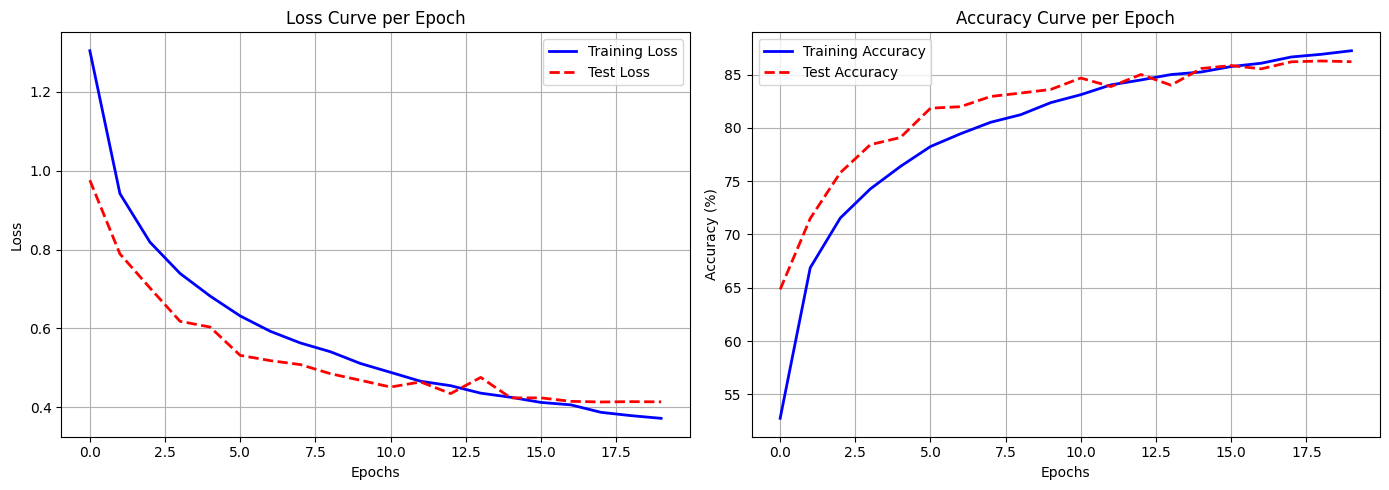

In [41]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(test_losses, label='Test Loss', color='red', linestyle='--', linewidth=2)
plt.title('Loss Curve per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(test_accuracies, label='Test Accuracy', color='red', linestyle='--', linewidth=2)
plt.title('Accuracy Curve per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Confusion Matrix Generation
This cell performs a full-dataset inference sweep to analyze exact class classification errors, outputting a standard raw-count confusion matrix alongside a customized percentage error matrix.

### Statistical Output Components:
**Confusion Matrix Plot:** A standard heatmap displaying raw classification tallies across all 10 target labels to verify overall categorical performance.


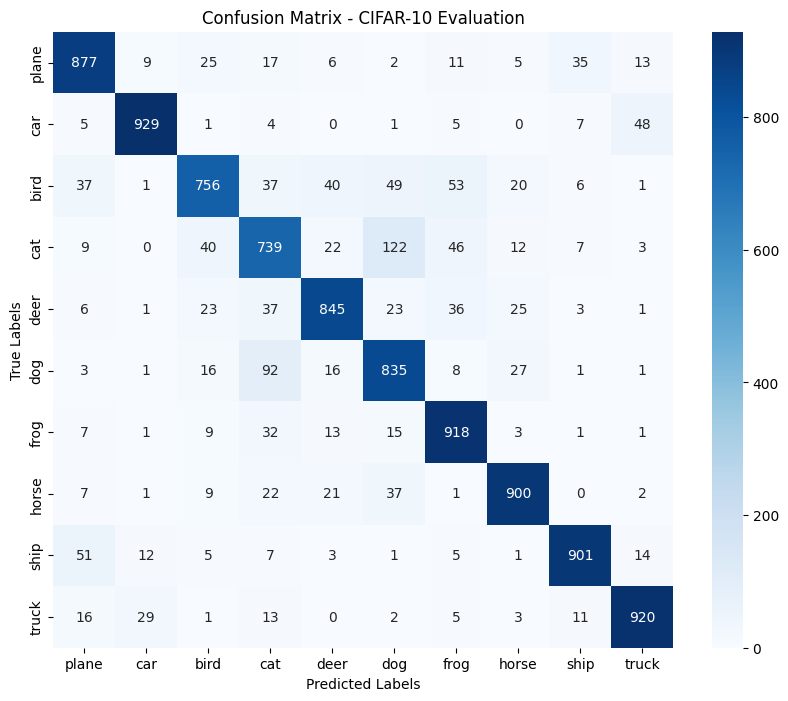

In [44]:
net.load_state_dict(torch.load('./cifar_net_advanced.pth'))
net.to(device)
net.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - CIFAR-10 Evaluation')
plt.show()

# 5. Spatial Feature Map Extraction & Activation Map Rendering
This cell isolates intermediate layer responses within the network to inspect internal computer vision representations.

### Analytical Procedure:
1. **Sample Acquisition:** Pulls a single data entry tensor from the validation loader dataset.
2. **Denormalization:** Reverses the tensor's standardization transforms to reconstruct the source RGB image array for contextual reference.
3. **Forward Hook Simulation:** Executes a direct mathematical evaluation through the initial `conv1` parameters.
4. **Subplot Mapping:** Renders the first 16 activated feature dimensions into an array grid, isolating visual attributes such as extracted edge orientations, textural fields, and color contrast shifts.

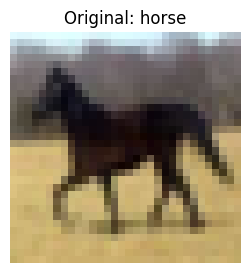

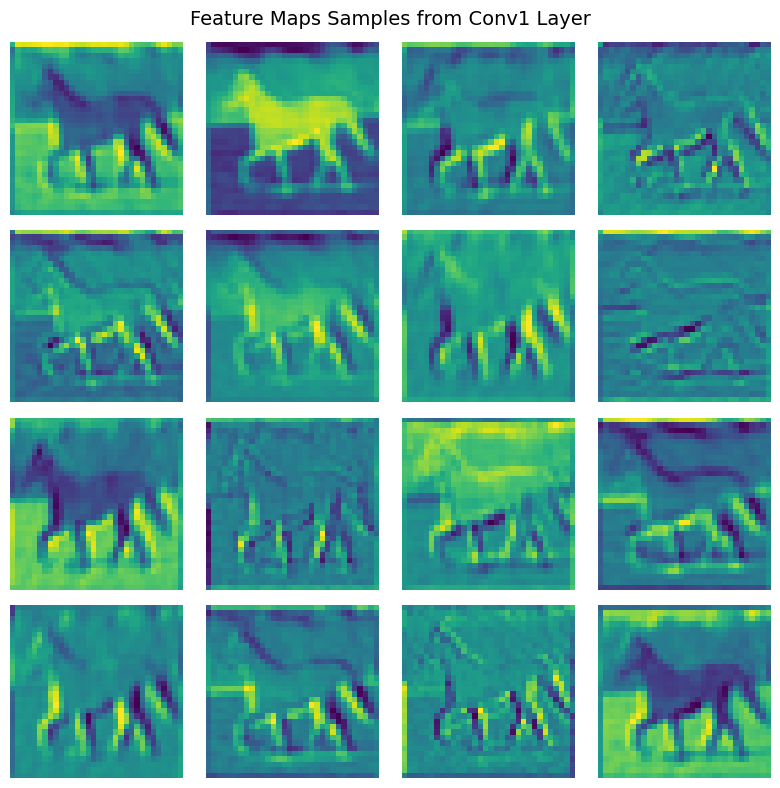

In [59]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
single_image = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    feature_maps = net.conv1(single_image)

feature_maps = feature_maps.squeeze(0).cpu().numpy()

plt.figure(figsize=(3,3))
inv_trans = transforms.Normalize(mean=[-0.5/0.5, -0.5/0.5, -0.5/0.5], std=[1/0.5, 1/0.5, 1/0.5])
original_img = inv_trans(images[0]).permute(1, 2, 0).numpy()
plt.imshow(np.clip(original_img, 0, 1))
plt.title(f"Original: {class_names[labels[0]]}")
plt.axis('off')
plt.show()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('Feature Maps Samples from Conv1 Layer', fontsize=14)

for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[0]:
        ax.imshow(feature_maps[i], cmap='viridis')
        ax.axis('off')
plt.tight_layout()
plt.show()